import libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

load + preprocessing data

In [ ]:
df = pd.read_csv("hotel_bookings.csv")

# Missing values
df['children'].fillna(0, inplace=True)
df['country'].fillna(df['country'].mode()[0], inplace=True)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Feature Engineering
df['total_guests'] = (
    df['adults'] +
    df['children'] +
    df['babies']
)

df['total_stay'] = (
    df['stays_in_weekend_nights'] +
    df['stays_in_week_nights']
)

df['is_family'] = np.where(df['total_guests'] > 2, 1, 0)

df['revenue'] = df['adr'] * df['total_stay']

/tmp/ipykernel_15059/1118217040.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(0, inplace=True)
/tmp/ipykernel_15059/1118217040.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

select important features

In [ ]:
selected_features = [
    'hotel',
    'lead_time',
    'arrival_date_month',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',
    'babies',
    'meal',
    'market_segment',
    'distribution_channel',
    'is_repeated_guest',
    'previous_cancellations',
    'booking_changes',
    'deposit_type',
    'days_in_waiting_list',
    'customer_type',
    'adr',
    'total_guests',
    'total_stay',
    'is_family'
]

X = df[selected_features]

y = df['is_canceled']

Encode categorical data

In [ ]:
label_encoder = LabelEncoder()

for column in X.select_dtypes(include='object').columns:
    X[column] = label_encoder.fit_transform(X[column])

/tmp/ipykernel_15059/3809305910.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = label_encoder.fit_transform(X[column])
/tmp/ipykernel_15059/3809305910.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = label_encoder.fit_transform(X[column])
/tmp/ipykernel_15059/3809305910.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

Train and Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression

In [ ]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.7477111467154955


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7155527580682078


Random forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7581826504921034


Model comparison table

In [ ]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.747711
1,Decision Tree,0.715553
2,Random Forest,0.758183


Confusion matrix

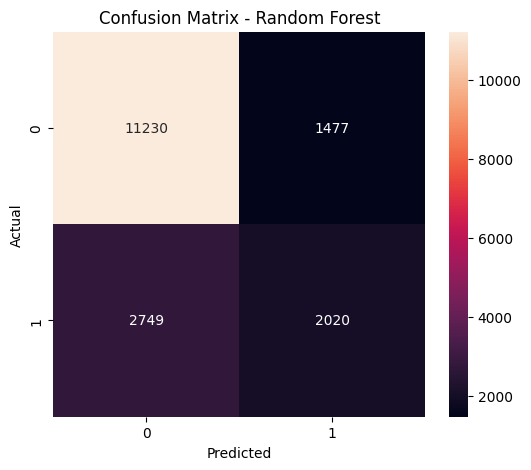

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Classification Report

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84     12707
           1       0.58      0.42      0.49      4769

    accuracy                           0.76     17476
   macro avg       0.69      0.65      0.67     17476
weighted avg       0.74      0.76      0.75     17476



ROC Curve

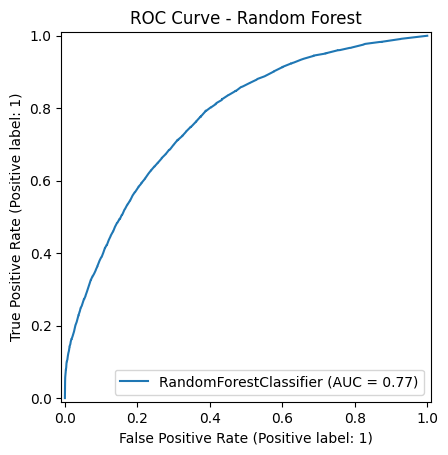

In [ ]:
RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.show()

In [14]:
import joblib

# Save trained Random Forest model
joblib.dump(rf_model, "random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [15]:
import os

os.listdir()

['.config', 'hotel_bookings.csv', 'random_forest_model.pkl', 'sample_data']